# Dynamics and Predictive Power of the Variance Risk Premium in S&P500 Options
## Part 2 - Estimation and Analysis of model 

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
import warnings, os, glob
from statsmodels.stats.diagnostic import acorr_breusch_godfrey, het_white
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm
from scipy import stats
import yfinance as yf 
import pickle

from utilities.ts_construction import extract_daily_metrics
from utilities.linear_regression import ols, reg_table
from utilities.fixed_random_effects import within_estimator, build_surface_panel


In [44]:
# ── Pour recharger dans un autre notebook ─────────────────────────────────────
with open('time_series.pkl', 'rb') as f:
    ts = pickle.load(f)
reg_overlap    = ts['reg_overlap']
reg_nonoverlap = ts['reg_nonoverlap']
metrics        = ts['metrics']
df             = ts['df']
spot_ts         = ts['spot_ts']

In [45]:
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans',
})

# ── User settings ──────────────────────────────────────────────────────────────
DATA_FOLDER   = './data'        # folder containing all YYYY-MM-DD.csv files
TARGET_TENOR  = 30              # target tenor in days for daily metrics
WING_LOW      = -0.15           # put-wing lower bound (log-moneyness)
WING_HIGH_PUT = -0.05           # put-wing upper bound
WING_LOW_CALL =  0.05           # call-wing lower bound
WING_HIGH     =  0.15           # call-wing upper bound
RV_WINDOW     = 21              # rolling window for realized vol (trading days)

print("Libraries loaded")

Libraries loaded


## 1 · Regression analysis

We implement OLS from scratch:

$$\hat\beta = (X'X)^{-1}X'y, \qquad s^2 = \frac{\hat\varepsilon'\hat\varepsilon}{n-k}, \qquad \widehat{\text{Var}}(\hat\beta) = s^2(X'X)^{-1}$$

**Dependent variable** $y_t = RV^{\text{fwd}}_t$: annualized realized volatility over the
21 trading days following day $t$:

$$RV^{\text{fwd}}_t = \sqrt{252}\cdot\hat\sigma(r_{t+1},\ldots,r_{t+21})$$

**Regressors**: ATM IV at constant 30-day maturity (VIX methodology), skew, convexity.

We estimate four nested models: M1 ⊂ M2 ⊂ M3, then M4 as the parsimonious specification.

In [46]:
y = reg_overlap['rv_forward']

In [47]:
# Import VIX index from yahoofinance 

vix = yf.Ticker("^VIX")
hist = vix.history(start="2017-06-09", end = "2018-06-08")
Vix_close = hist["Close"]

reg_base = reg_overlap.copy()   # protect reg before adding VIX
Vix_close.index = Vix_close.index.tz_localize(None)
reg = reg_base.join(Vix_close.rename("vix"), how="left")
# VIX en décimal — cohérent avec tout le reste
reg['vix_norm'] = reg['vix'] / 100


### Model 1 — Mincer-Zarnowitz regression (baseline)

$$RV^{\text{fwd}}_t = \alpha + \beta_1 \cdot IV_t + \varepsilon_t$$

**Interpretation**:
- If $\alpha = 0$ and $\beta_1 = 1$: IV is an **unbiased predictor** of future RV
- In practice: $\beta_1 < 1$ and $\alpha > 0$ → IV **over-estimates** RV on average (= VRP)

In [48]:
print("═"*62)
print("MODEL 1 — Baseline: RV_fwd ~ ATM_IV")
print("═"*62)
r1 = ols(y, reg[['atm_iv']])
reg_table(r1, ['Const', 'ATM_IV'])

══════════════════════════════════════════════════════════════
MODEL 1 — Baseline: RV_fwd ~ ATM_IV
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0112    0.0171    0.658    0.5114 
ATM_IV                    0.8192    0.1266    6.471    0.0000 ***
──────────────────────────────────────────────────────────────
R²                        0.1669
Adj. R²                   0.1629
N                            211
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


### Model 2 — Adding skew

$$RV^{\text{fwd}}_t = \alpha + \beta_1 \cdot IV_t + \beta_2 \cdot \text{Skew}_t + \varepsilon_t$$


In [49]:
print("\n" + "═"*62)
print("MODEL 2 — RV_fwd ~ ATM_IV + Skew")
print("═"*62)
r2 = ols(y, reg[['atm_iv', 'skew']])
reg_table(r2, ['Const', 'ATM_IV', 'Skew'])


══════════════════════════════════════════════════════════════
MODEL 2 — RV_fwd ~ ATM_IV + Skew
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0603    0.0213    2.838    0.0051 **
ATM_IV                    0.9124    0.1544    5.909    0.0000 ***
Skew                     -0.6913    0.2221   -3.112    0.0022 **
──────────────────────────────────────────────────────────────
R²                        0.1798
Adj. R²                   0.1695
N                            163
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


### Model 3 — Full model

$$RV^{\text{fwd}}_t = \alpha + \beta_1 \cdot IV_t + \beta_2 \cdot \text{Skew}_t + \beta_3 \cdot \text{Convexity}_t + \varepsilon_t$$

In [50]:
print("\n" + "═"*62)
print("MODEL 3 — RV_fwd ~ ATM_IV + Skew + Convexity")
print("═"*62)
r3 = ols(y, reg[['atm_iv', 'skew', 'convexity']])
reg_table(r3, ['Const', 'ATM_IV', 'Skew', 'Convexity'])


══════════════════════════════════════════════════════════════
MODEL 3 — RV_fwd ~ ATM_IV + Skew + Convexity
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0183    0.0300    0.611    0.5424 
ATM_IV                    1.1146    0.1845    6.043    0.0000 ***
Skew                     -0.7201    0.2207   -3.263    0.0013 **
Convexity                 0.6475    0.3296    1.965    0.0512 
──────────────────────────────────────────────────────────────
R²                        0.1992
Adj. R²                   0.1841
N                            163
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


### Model 4 - Ading the VIX

In [51]:
print("\n" + "═"*62)
print("MODEL 4 — RV_fwd ~ ATM_IV + Skew + Convexity+ vix")
print("═"*62)
r4 = ols(y, reg[['atm_iv', 'skew', 'convexity' , 'vix']])
reg_table(r4, ['Const', 'ATM_IV','skew', 'Convexity' , 'vix'])


══════════════════════════════════════════════════════════════
MODEL 4 — RV_fwd ~ ATM_IV + Skew + Convexity+ vix
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.1150    0.0443    2.593    0.0104 *
ATM_IV                   -0.3553    0.5368   -0.662    0.5091 
skew                     -0.7545    0.2160   -3.493    0.0006 ***
Convexity                -0.9389    0.6337   -1.482    0.1404 
vix                       0.0102    0.0035    2.907    0.0042 **
──────────────────────────────────────────────────────────────
R²                        0.2399
Adj. R²                   0.2206
N                            163
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


## Model 5 - Skew + VIX

In [52]:
print("\n" + "═"*62)
print("MODEL 5 — RV_fwd ~ Skew + vix")
print("═"*62)
r5 = ols(y, reg[['skew', 'vix']])
reg_table(r5, ['Const', 'Skew' , 'Vix'])


══════════════════════════════════════════════════════════════
MODEL 5 — RV_fwd ~ Skew + vix
══════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.0682    0.0195    3.491    0.0006 ***
Skew                     -0.6653    0.2113   -3.149    0.0020 **
Vix                       0.0079    0.0012    6.643    0.0000 ***
──────────────────────────────────────────────────────────────
R²                        0.2168
Adj. R²                   0.2070
N                            163
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


## Model 6 - transform the variable

In [53]:
reg['vix_atm_spread'] = reg['vix_norm'] - reg['atm_iv']

# Reconstruire y proprement sur le bon index
y = reg['rv_forward'].dropna()
common_idx = y.index.intersection(
    reg[['atm_iv', 'skew', 'convexity', 'vix_atm_spread']].dropna().index
)
y_clean = y.loc[common_idx]
X_clean = reg.loc[common_idx, ['atm_iv', 'skew', 'convexity', 'vix_atm_spread']]

r6 = ols(y_clean, X_clean)
reg_table(r6, ['Const', 'ATM_IV', 'Skew', 'Convexity', 'VIX_ATM_Spread'])


──────────────────────────────────────────────────────────────
Variable                    Coef        SE        t         p
──────────────────────────────────────────────────────────────
Const                     0.1150    0.0443    2.593    0.0104 *
ATM_IV                    0.6688    0.2367    2.826    0.0053 **
Skew                     -0.7545    0.2160   -3.493    0.0006 ***
Convexity                -0.9389    0.6337   -1.482    0.1404 
VIX_ATM_Spread            1.0241    0.3523    2.907    0.0042 **
──────────────────────────────────────────────────────────────
R²                        0.2399
Adj. R²                   0.2206
N                            163
──────────────────────────────────────────────────────────────
Significance: * p<0.05  ** p<0.01  *** p<0.001


In [54]:
data  = reg[['atm_iv', 'skew', 'convexity' , 'vix_atm_spread' ,'rv_forward']].dropna()
y_m6  = data['rv_forward'].values
X_m6  = sm.add_constant(data[['atm_iv', 'skew', 'convexity' , 'vix_atm_spread']].values)

res_ols = sm.OLS(y_m6, X_m6).fit()
resid = res_ols.resid

jb_stat,    jb_p          = stats.jarque_bera(resid)
dw                         = durbin_watson(resid)
bg_stat,    bg_p,   _, _  = acorr_breusch_godfrey(res_ols, nlags=21)
white_stat, white_p, _, _ = het_white(resid, X_m6)

print(f"Jarque-Bera     : stat={jb_stat:.3f}  p={jb_p:.4f}  "
      f"{'reject normality'          if jb_p    < 0.05 else 'cannot reject normality'}")
print(f"Durbin-Watson   : {dw:.4f}            "
      f"{'autocorrelation present'   if abs(dw-2)>0.5  else 'no strong autocorrelation'}")
print(f"White           : stat={white_stat:.3f}  p={white_p:.4f}  "
      f"{'reject homoscedasticity'   if white_p < 0.05 else 'cannot reject homoscedasticity'}")
print(f"Breusch-Godfrey : stat={bg_stat:.3f}  p=  {bg_p:.4f}  "
      f"{'reject no autocorrelation' if bg_p    < 0.05 else 'cannot reject no autocorrelation'}")

Jarque-Bera     : stat=47.597  p=0.0000  reject normality
Durbin-Watson   : 0.1341            autocorrelation present
White           : stat=62.030  p=0.0000  reject homoscedasticity
Breusch-Godfrey : stat=148.402  p=  0.0000  reject no autocorrelation


### Newey-West (HAC) correction

Corrects simultaneously for autocorrelation and heteroscedasticity:

$$\widehat{\text{Var}}_{NW}(\hat\beta) = (X'X)^{-1}\hat\Omega_{NW}(X'X)^{-1}$$

Number of lags = 20 (= RV window $-$ 1), following the overlapping structure of $y_t$.


In [55]:
res_nw  = sm.OLS(y_m6, X_m6).fit(cov_type='HAC', cov_kwds={'maxlags': 20})

print(res_nw.summary())

jb_stat,    jb_p          = stats.jarque_bera(res_nw.resid)
dw                         = durbin_watson(res_nw.resid)
bg_stat,    bg_p,   _, _  = acorr_breusch_godfrey(res_nw, nlags=21)
white_stat, white_p, _, _ = het_white(res_nw.resid, X_m6)

print(f"Jarque-Bera     : stat={jb_stat:.3f}  p={jb_p:.4f}  "
      f"{'reject normality'          if jb_p    < 0.05 else 'cannot reject normality'}")
print(f"Durbin-Watson   : {dw:.4f}            "
      f"{'autocorrelation present'   if abs(dw-2)>0.5  else 'no strong autocorrelation'}")
print(f"White           : stat={white_stat:.3f}  p={white_p:.4f}  "
      f"{'reject homoscedasticity'   if white_p < 0.05 else 'cannot reject homoscedasticity'}")
print(f"Breusch-Godfrey : stat={bg_stat:.3f}  p=  {bg_p:.4f}  "
      f"{'reject no autocorrelation' if bg_p    < 0.05 else 'cannot reject no autocorrelation'}")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.221
Method:                 Least Squares   F-statistic:                     3.936
Date:                Sat, 23 May 2026   Prob (F-statistic):            0.00449
Time:                        12:46:11   Log-Likelihood:                 201.76
No. Observations:                 163   AIC:                            -393.5
Df Residuals:                     158   BIC:                            -378.1
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1150      0.065      1.767      0.0

## Conclusion

- **ATM IV significantly predicts forward RV** (β = 0.82, R² = 0.167), consistent 
  with Mincer-Zarnowitz. The VRP is positive on average — investors systematically 
  overpay for volatility protection.

- **Skew and convexity do not survive HAC correction.** In-sample significance 
  disappears once overlapping-window autocorrelation (DW = 0.13, ρ̂₁ ≈ 0.875) is 
  accounted for with Newey-West (20 lags). The parsimonious model reduces to ATM IV alone.

- **VIX carries information beyond ATM IV.** Reparametrizing as ATM IV + (VIX − ATM IV) 
  resolves multicollinearity (condition number 133 vs 2200) and both regressors remain 
  significant after HAC (p = 0.043 and p = 0.041). Our surface interpolation does not 
  fully replicate the CBOE signal.

## 2 · Fixed Effects & Random Effects — IV Surface Panel

### 2.1 Motivation

A pooled OLS mixing all 22 expiries confounds two effects:
- The **causal** relationship: when IV rises, does future RV rise?
- The **term structure**: long-dated options have structurally higher IV

We verify this with an **F-test on entity fixed effects**:

$$F = \frac{(SSR_{\text{pooled}} - SSR_{\text{FE}})/(N-1)}{SSR_{\text{FE}}/(NT-N-K)} \sim F(N-1,\ NT-N-K)$$

### 2.2 Fixed Effects — within estimator

$$RV^{\text{fwd}}_t = \alpha_i + \beta_1 IV_{it} + \beta_2 \text{Conv}_{it} + \varepsilon_{it}$$

$\alpha_i$ absorbs the average IV level of each expiry. Identification from within-expiry deviations:

$$\tilde{y}_{it} = y_{it} - \bar{y}_i, \qquad \tilde{x}_{it} = x_{it} - \bar{x}_i$$

### 2.3 Random Effects — GLS via quasi-demeaning

Assumes $\alpha_i \sim \mathcal{N}(0,\sigma^2_\alpha)$ uncorrelated with regressors.
Quasi-demeaning parameter:

$$\theta = 1 - \sqrt{\frac{\sigma^2_\varepsilon}{\sigma^2_\varepsilon + T\cdot\sigma^2_\alpha}}$$

### 2.4 Hausman test

$$H_0: \alpha_i \perp X_{it} \implies \text{RE consistent}$$

$$H = (\hat\beta_{FE}-\hat\beta_{RE})^\top[\text{Var}(\hat\beta_{FE})-\text{Var}(\hat\beta_{RE})]^{-1}(\hat\beta_{FE}-\hat\beta_{RE}) \sim \chi^2(K)$$

Reject $H_0$ → entity effects correlated with regressors → **FE is the consistent estimator**.

In [56]:
from linearmodels.panel import PanelOLS, RandomEffects

# ── Panel construction ─────────────────────────────────────────────────────────
panel_surf = build_surface_panel(df, reg_base,
                                 wing_lo=WING_LOW, wing_hi_p=WING_HIGH_PUT,
                                 wing_lo_c=WING_LOW_CALL, wing_hi=WING_HIGH)

# ── Ajout du VIX_ATM_Spread (varie par date, broadcast sur toutes les expiries) ─
vix_norm = reg['vix'] / 100
panel_surf['vix_norm'] = panel_surf['date'].map(vix_norm)
panel_surf['vix_atm_spread'] = panel_surf['vix_norm'] - panel_surf['atm_iv']
panel_surf = panel_surf.dropna(subset=['vix_atm_spread'])

x_cols = ['atm_iv', 'vix_atm_spread']

print(f"Panel: {len(panel_surf)} obs  |  {panel_surf['expiry'].nunique()} expiries  |  {panel_surf['date'].nunique()} dates")

# ── F-test: are entity fixed effects significant? ──────────────────────────────
r_pooled = ols(panel_surf['rv_forward'].values, panel_surf[x_cols].values)
fe_surf  = within_estimator(panel_surf, 'rv_forward', x_cols, 'expiry')
N, NT, K = panel_surf['expiry'].nunique(), len(panel_surf), len(x_cols)
F_stat   = ((np.sum(r_pooled['resid']**2) - np.sum(fe_surf.resid**2)) / (N-1)) / \
            (np.sum(fe_surf.resid**2) / (NT - N - K))
F_p      = 1 - stats.f.cdf(F_stat, N-1, NT-N-K)
print(f"\nF-test entity effects : F = {F_stat:.3f},  p = {F_p:.4f}  → {'Significant ✓' if F_p < 0.05 else 'Not significant'}")

# ── Fixed Effects & Random Effects (linearmodels) ──────────────────────────────
panel_idx = panel_surf.set_index(['expiry', 'date'])
y_pan = panel_idx['rv_forward']
X_pan = sm.add_constant(panel_idx[x_cols])

fe_lm = PanelOLS(y_pan, X_pan[x_cols], entity_effects=True).fit()
re_lm = RandomEffects(y_pan, X_pan).fit()

print('\n' + '═'*62)
print('FIXED EFFECTS'); print(fe_lm.summary.tables[1])
print('\n' + '═'*62)
print('RANDOM EFFECTS'); print(re_lm.summary.tables[1])

Panel: 2240 obs  |  21 expiries  |  211 dates

F-test entity effects : F = 17.040,  p = 0.0000  → Significant ✓

══════════════════════════════════════════════════════════════
FIXED EFFECTS
                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
atm_iv             0.0026     0.0867     0.0295     0.9765     -0.1674      0.1726
vix_atm_spread     0.6518     0.0517     12.600     0.0000      0.5504      0.7533

══════════════════════════════════════════════════════════════
RANDOM EFFECTS
                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
const              0.0965     0.0124     7.7706     0.0000      0.0

### 2.4 Hausman test — choosing between FE and RE

$$H_0: \alpha_i \perp X_{it} \quad \Rightarrow \text{RE consistent and efficient}$$

$$H = (\hat\beta_{FE} - \hat\beta_{RE})^\top\,[\text{Var}(\hat\beta_{FE}) - \text{Var}(\hat\beta_{RE})]^{-1}\,(\hat\beta_{FE} - \hat\beta_{RE}) \sim \chi^2(K)$$

- **Reject** $H_0$: expiry effects correlated with regressors → only **FE** is consistent
- **Cannot reject**: RE is consistent and more efficient → **prefer RE**

In [57]:
b_fe  = fe_lm.params.values
b_re  = re_lm.params[x_cols].values
V_fe  = fe_lm.cov.values
V_re  = re_lm.cov.loc[x_cols, x_cols].values
diff  = b_fe - b_re
H     = float(diff @ np.linalg.inv(V_fe - V_re) @ diff)
p     = 1 - stats.chi2.cdf(H, df=len(b_fe))
print(f"Hausman : stat={H:.4f}  p={p:.4f}")

Hausman : stat=12.9536  p=0.0015


### Conclusion : 
fixed effect within expiries

# 3. ARMA
(for a single TS -> atm_iv)

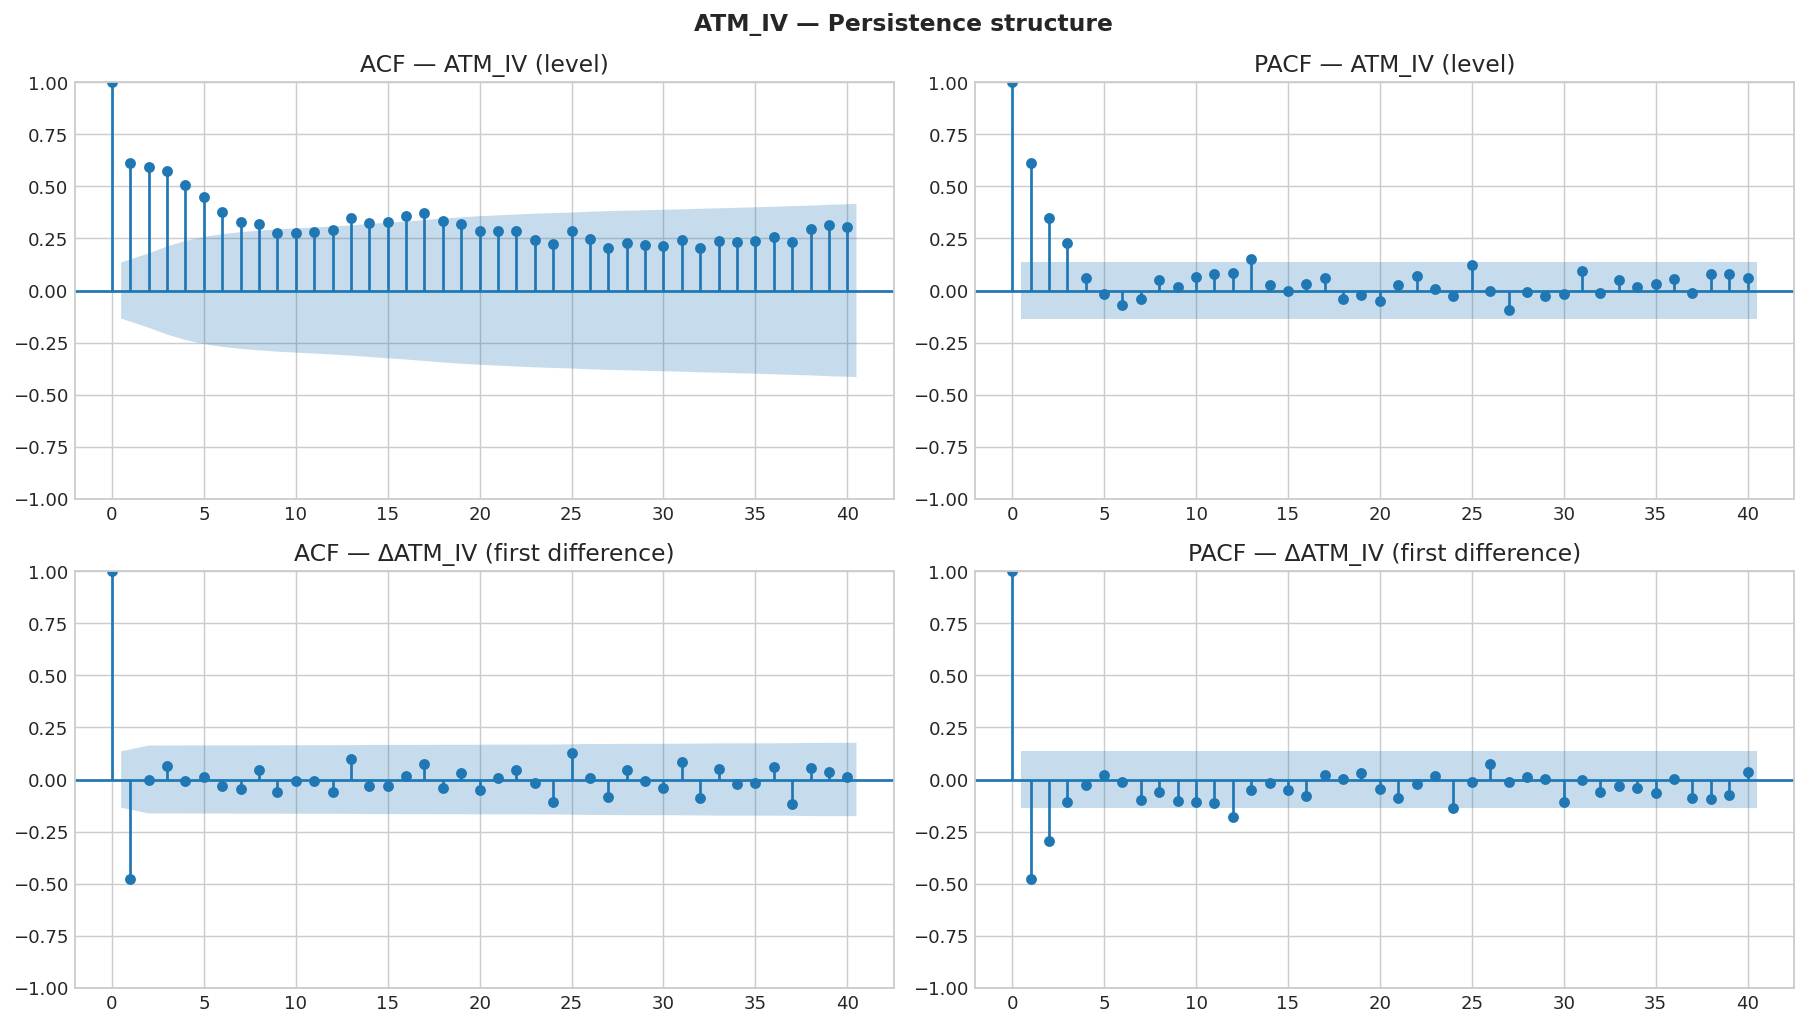

In [58]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ACF et PACF en niveau
plot_acf(reg['atm_iv'].dropna(), lags=40, ax=axes[0,0], 
         title='ACF — ATM_IV (level)')
plot_pacf(reg['atm_iv'].dropna(), lags=40, ax=axes[0,1], 
          title='PACF — ATM_IV (level)')

# ACF et PACF en différence première
atm_iv_diff = reg['atm_iv'].dropna().diff().dropna()
plot_acf(atm_iv_diff, lags=40, ax=axes[1,0], 
         title='ACF — ΔATM_IV (first difference)')
plot_pacf(atm_iv_diff, lags=40, ax=axes[1,1], 
          title='PACF — ΔATM_IV (first difference)')

plt.suptitle('ATM_IV — Persistence structure', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [59]:
# stationnarity

from statsmodels.tsa.stattools import adfuller
result = adfuller(reg['atm_iv'].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -3.3225
p-value: 0.0139


p<0.05 now -> it is stationnary

Best ARIMA order: (p=3, d=0, q=0) with AIC=-886.45


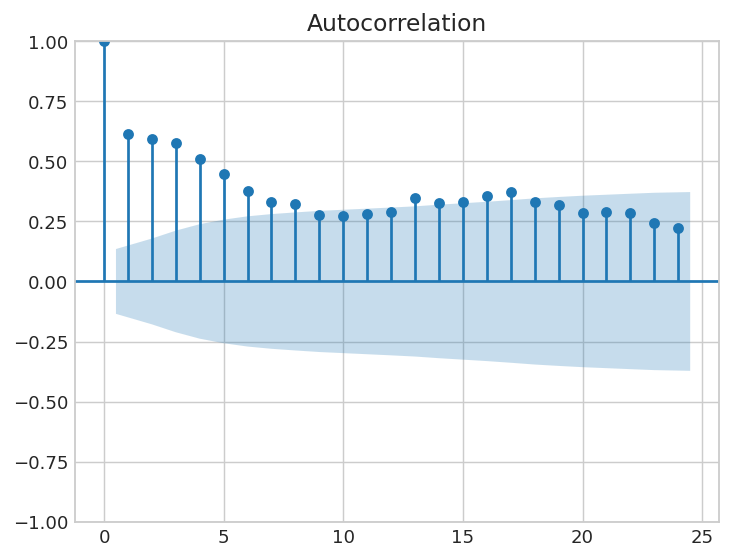

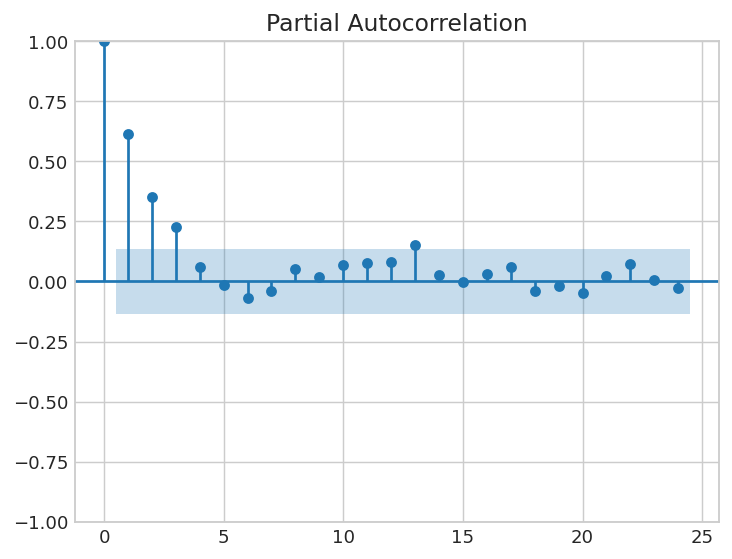

In [60]:
# identfy p and q

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(reg['atm_iv'].dropna())  # gives p
plot_pacf(reg['atm_iv'].dropna())   # gives q

from statsmodels.tsa.arima.model import ARIMA
import itertools

best_aic = np.inf
for p,q in itertools.product(range(4), range(4)):
    try:
        model = ARIMA(reg['atm_iv'].dropna(), order=(p,0,q)).fit()
        if model.aic < best_aic:
            best_aic = model.aic
            best_p, best_q = p, q
    except:
        continue
print(f"Best ARIMA order: (p={best_p}, d=0, q={best_q}) with AIC={best_aic:.2f}")

In [61]:
model = ARIMA(reg['atm_iv'].dropna(), order=(best_p,0,best_q)).fit()
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                 atm_iv   No. Observations:                  211
Model:                 ARIMA(3, 0, 0)   Log Likelihood                 448.226
Date:                Sat, 23 May 2026   AIC                           -886.451
Time:                        12:46:17   BIC                           -869.692
Sample:                             0   HQIC                          -879.677
                                - 211                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1282      0.020      6.425      0.000       0.089       0.167
ar.L1          0.3151      0.041      7.624      0.000       0.234       0.396
ar.L2          0.2600      0.081      3.225      0.0

Kurtosis = 88.21 → extreme fat tails (normal distribution has kurtosis = 3)

JB huge -> residuals non gaussian

heteroskedasticity : we reject it, the variance is not constant

In [62]:
# ljung-box test : check that autocorr is low
from statsmodels.stats.diagnostic import acorr_ljungbox
acorr_ljungbox(model.resid, lags=10)

,lb_stat,lb_pvalue
1,0.034929,0.851744
2,0.094999,0.953611
3,0.115030,0.989975
4,1.523140,0.822535
5,1.640103,0.896358
6,2.156801,0.904727
7,3.115010,0.874163
8,3.121464,0.926505
9,4.154511,0.900952
10,4.915395,0.896758


p-value > 0.05, residuals are WN

Recap ARMA : for now just did with atm_iv, test with vix or skew or convexity ?

## 4. Cointegration

In [63]:
from statsmodels.tsa.stattools import coint, adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# ── 1. Préparer les données ────────────────────────────────────────────────────
data_coint = reg[['atm_iv', 'rv_past']].dropna().copy()
data_coint['vix_norm'] = reg['vix'] / 100
data_coint = data_coint.dropna()

# ── 2. Vérifier I(1) : ADF  ───────────────────────────
def integration_order(series, name):
    # ADF : H0 = unit root
    adf_stat, adf_p, _, _, _, _ = adfuller(series, autolag='AIC')
    
    adf_reject = adf_p < 0.05  # reject H0 → stationary
    
    if adf_reject:
        conclusion = "I(0) — stationary"
    else:
        conclusion = "I(1) — cannot reject unit root"
    
    print(f"{name:<12} ADF stat={adf_stat:.4f}  p={adf_p:.4f} "
          f"{'[reject H0]' if adf_reject else '[fail to reject]'}  → {conclusion}")

print("═"*72)
print("INTEGRATION order")
print("═"*72)
for col, name in [('atm_iv','ATM_IV'), ('rv_past','RV_past'), ('vix_norm','VIX_norm')]:
    integration_order(data_coint[col], name)

# ── 3. Engle-Granger dans les deux sens ───────────────────────────────────────
print("\n" + "═"*72)
print("ENGLE-GRANGER (two directions)")
print("═"*72)
pairs = [
    ('vix_norm', 'atm_iv',  'VIX → ATM_IV'),
    ('atm_iv',   'vix_norm','ATM_IV → VIX'),
    ('vix_norm', 'rv_past', 'VIX → RV_past'),
    ('rv_past',  'vix_norm','RV_past → VIX'),
    ('atm_iv',   'rv_past', 'ATM_IV → RV_past'),
    ('rv_past',  'atm_iv',  'RV_past → ATM_IV'),
]
for x, y, label in pairs:
    _, p, _ = coint(data_coint[x], data_coint[y])
    print(f"  {label:<22} p = {p:.4f}  {'COINTEGRATED ✓' if p < 0.05 else 'not cointegrated'}")

# ── 4. Johansen (symétrique, rang de cointégration) ───────────────────────────
print("\n" + "═"*72)
print("JOHANSEN — cointegration rank  (det_order=0, k_ar_diff=1)")
print("═"*72)
res_joh = coint_johansen(data_coint[['vix_norm', 'atm_iv', 'rv_past']],
                         det_order=0, k_ar_diff=1)

print("\nTrace statistic vs critical values (90% / 95% / 99%)")
print(f"{'H0: rang ≤':<12} {'Trace stat':>12} {'CV 90%':>10} {'CV 95%':>10} {'CV 99%':>10}")
print("-"*56)
for i in range(len(res_joh.lr1)):
    ts  = res_joh.lr1[i]
    cvs = res_joh.cvt[i]   # [90%, 95%, 99%]
    reject = "← reject" if ts > cvs[1] else ""
    print(f"  r ≤ {i:<8} {ts:>12.3f} {cvs[0]:>10.3f} {cvs[1]:>10.3f} {cvs[2]:>10.3f}  {reject}")

════════════════════════════════════════════════════════════════════════
INTEGRATION order
════════════════════════════════════════════════════════════════════════
ATM_IV       ADF stat=-3.3225  p=0.0139 [reject H0]  → I(0) — stationary
RV_past      ADF stat=-1.9094  p=0.3277 [fail to reject]  → I(1) — cannot reject unit root
VIX_norm     ADF stat=-2.5859  p=0.0959 [fail to reject]  → I(1) — cannot reject unit root

════════════════════════════════════════════════════════════════════════
ENGLE-GRANGER (two directions)
════════════════════════════════════════════════════════════════════════
  VIX → ATM_IV           p = 0.1168  not cointegrated
  ATM_IV → VIX           p = 0.0025  COINTEGRATED ✓
  VIX → RV_past          p = 0.0015  COINTEGRATED ✓
  RV_past → VIX          p = 0.0027  COINTEGRATED ✓
  ATM_IV → RV_past       p = 0.0025  COINTEGRATED ✓
  RV_past → ATM_IV       p = 0.1364  not cointegrated

════════════════════════════════════════════════════════════════════════
JOHANSEN — co

## 5.VAR - first case

with atm_iv, skew and convexity (and vix ?)

In [64]:
# stationnarity

from statsmodels.tsa.stattools import adfuller
result = adfuller(reg['atm_iv'].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -3.3225
p-value: 0.0139


In [65]:
# stationnarity

from statsmodels.tsa.stattools import adfuller
result = adfuller(reg['skew'].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -4.2698
p-value: 0.0005


In [66]:
# stationnarity

from statsmodels.tsa.stattools import adfuller
result = adfuller(reg['convexity'].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -4.5923
p-value: 0.0001


The three are stationnary 

In [67]:
from statsmodels.tsa.vector_ar.var_model import VAR

# Build stationary dataframe for VAR
delta_var = pd.DataFrame({
    'atm_iv'   : reg['atm_iv'],   # ok stat
    'skew'      : reg['skew'],             # ok stat
    'convexity' : reg['convexity']         # ok stat
}).dropna()

print(delta_var.corr())
print("")

model_var = VAR(delta_var)
results = model_var.fit(maxlags=10, ic='aic')
print(results.summary())

             atm_iv      skew  convexity
atm_iv     1.000000  0.467811  -0.586474
skew       0.467811  1.000000  -0.226771
convexity -0.586474 -0.226771   1.000000

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 23, May, 2026
Time:                     12:46:18
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -23.5346
Nobs:                     161.000    HQIC:                  -23.7733
Log likelihood:           1262.54    FPE:                4.02329e-11
AIC:                     -23.9365    Det(Omega_mle):     3.54104e-11
--------------------------------------------------------------------
Results for equation atm_iv
                  coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------
const                0.027113         0.013631            

Remark : multicollinearity -> look at the covariance matrix, it is ok

Looking at the p-values :

for constant, it si closed to 0.05 so borderline : so marginally significant 

significant terms : L1 atm_iv and L2 atm_iv -> Yesterday's and two-days-ago's volatility impacts  today's vol. If vol was high yesterday, it wants to stay high today.
A high convexity yesterday ->  atm_iv higher today.
high skew two days ago -> atm_iv lower today

non significant terms : L1 skew and l2 conv

In [68]:
# granger causality tests
print(results.test_causality('atm_iv', ['skew', 'convexity'], kind='f'))

# Does ATM_IV Granger-cause skew ?
print(results.test_causality('skew', ['atm_iv'], kind='f'))

# Does ATM_IV Granger-cause convexity ?
print(results.test_causality('convexity', ['atm_iv'], kind='f'))

<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: ['skew', 'convexity'] do not Granger-cause atm_iv: reject at 5% significance level. Test statistic: 6.594, critical value: 2.391>, p-value: 0.000>
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: atm_iv does not Granger-cause skew: fail to reject at 5% significance level. Test statistic: 0.354, critical value: 3.015>, p-value: 0.702>
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: atm_iv does not Granger-cause convexity: fail to reject at 5% significance level. Test statistic: 0.082, critical value: 3.015>, p-value: 0.921>


first test : \
Result : reject Ho at 5%\
p val : 0\
Analysis : we reject the null that they don't cause anything -> it means they impact atm_iv

2nd test : \
Result : reject H   at 5% \
p val : 0.702 \
Analysis : past atm_iv tells nothing about present skew

3rd test : \
Result : reject H0 at 5% \
p val : 0.921 \
Analysis ; past atm_iv tells nothing about present conv

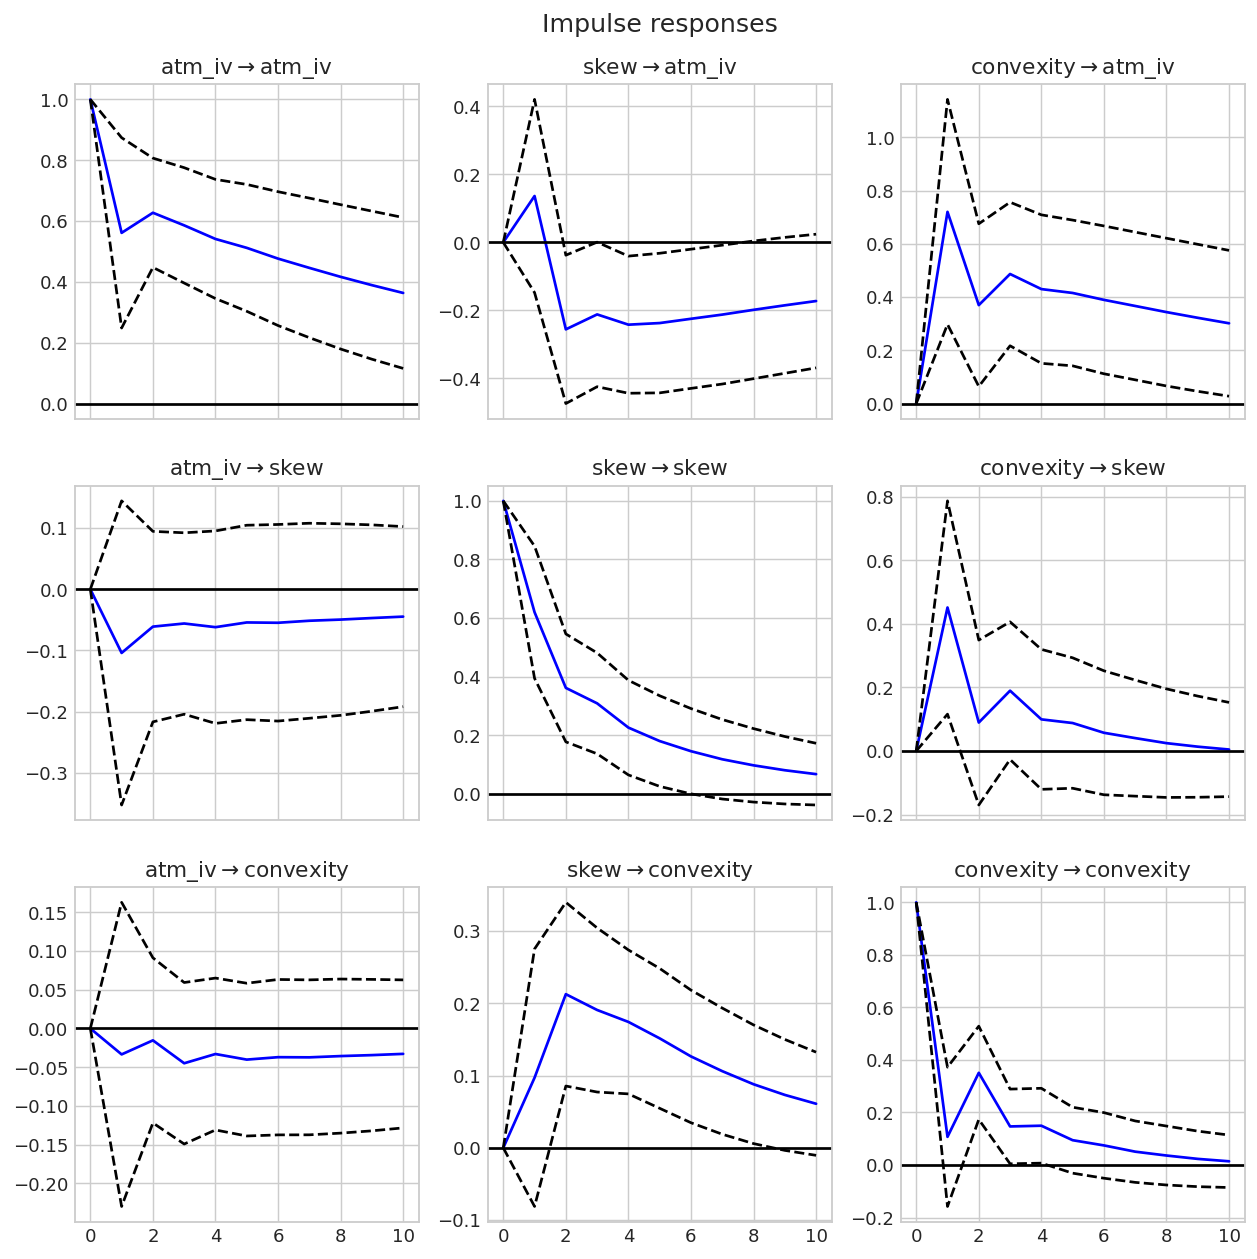

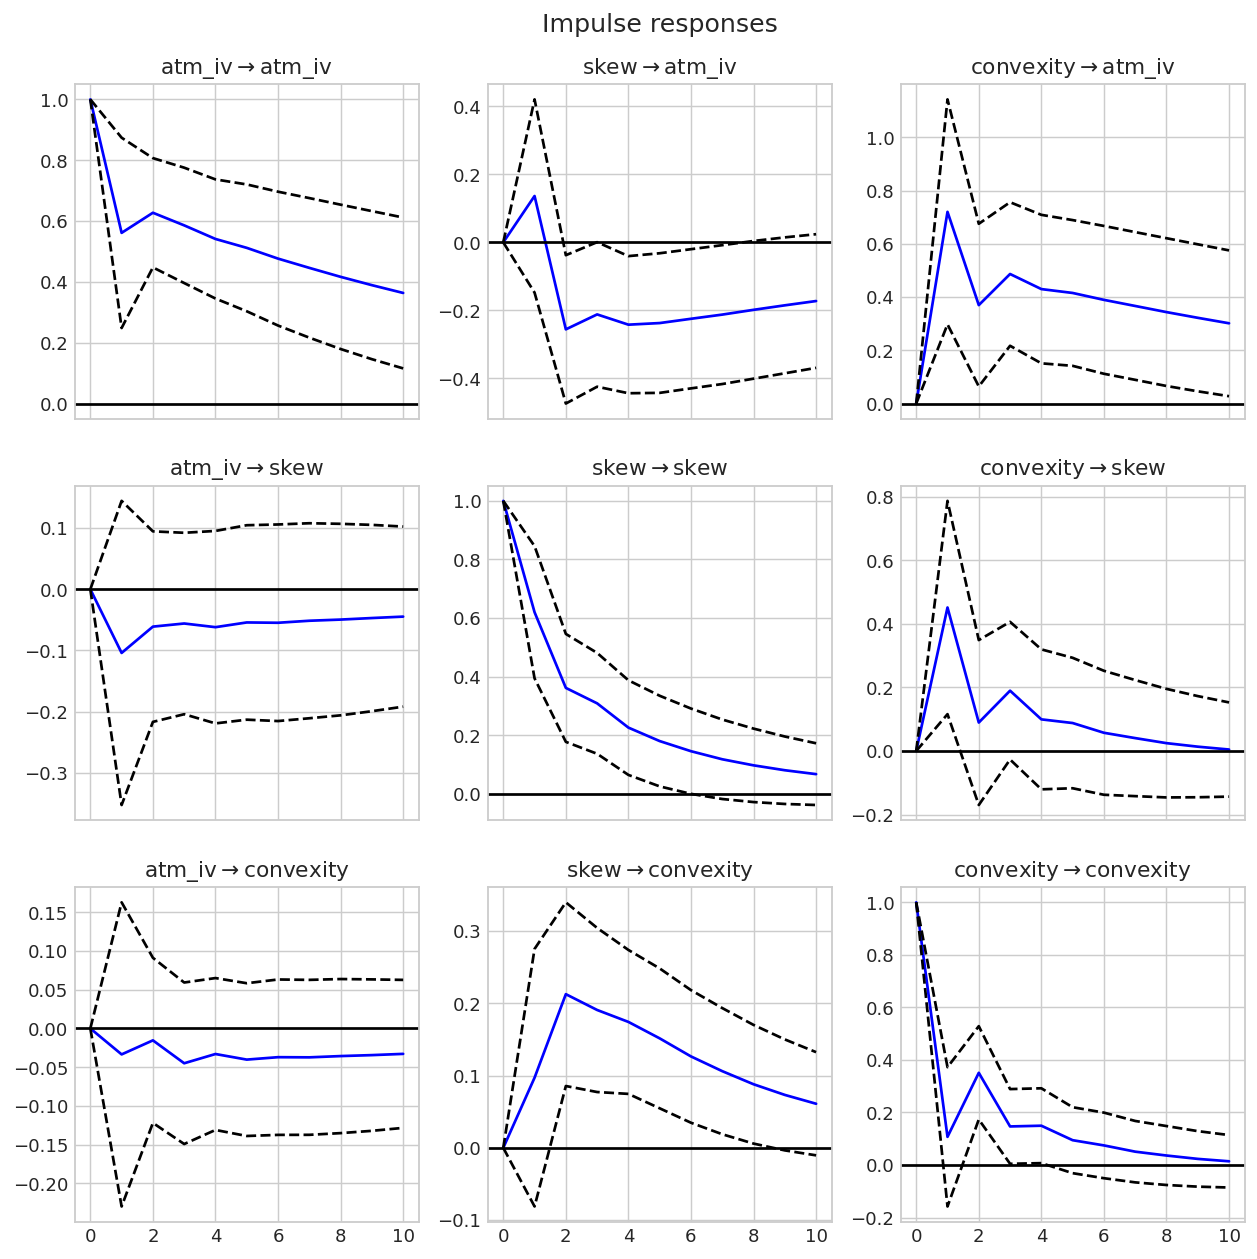

In [69]:
# impulse response functions
irf = results.irf(10) # 10 periods horizon
irf.plot(orth=False)

black lines -> confidence interval

read the IR : \
on the rows : variable that receive the shock \
on the columns : varaibel that responds \
example on the bottom left : how atm_iv responds to conv shock

# VAR - second case

VAR with atm_iv, skew, convexity and SP500 daily returns

In [70]:
# stationnarity

from statsmodels.tsa.stattools import adfuller
result = adfuller(np.log(spot_ts / spot_ts.shift(1)).dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -6.4767
p-value: 0.0000


In [71]:
from statsmodels.tsa.vector_ar.var_model import VAR

# Build stationary dataframe for VAR
delta_var = pd.DataFrame({
    'atm_iv'   : reg['atm_iv'],   # stat already
    'skew'      : reg['skew'],             # ok stat
    'convexity' : reg['convexity'],       # ok stat
    'ret'       : np.log(spot_ts / spot_ts.shift(1))         # ok stat
}).dropna()

print(delta_var.corr())
print("")

model_var = VAR(delta_var)
results = model_var.fit(maxlags=10, ic='aic')
print(results.summary())

             atm_iv      skew  convexity       ret
atm_iv     1.000000  0.467811  -0.586474 -0.380470
skew       0.467811  1.000000  -0.226771 -0.525155
convexity -0.586474 -0.226771   1.000000  0.202838
ret       -0.380470 -0.525155   0.202838  1.000000

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 23, May, 2026
Time:                     12:46:18
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -33.3370
Nobs:                     161.000    HQIC:                  -33.7463
Log likelihood:           1861.30    FPE:                1.67062e-15
AIC:                     -34.0260    Det(Omega_mle):     1.34396e-15
--------------------------------------------------------------------
Results for equation atm_iv
                  coefficient       std. error           t-stat            prob
-----------------------------------------------

Remark : multicollinearity -> look at the covariance matrix, it is ok

significant terms : L2 skew ; L2 atm_iv ; L1 ret ; const

non significant terms : L1 atm_iv ; L1.skew ; L1.conv ; L2.conv ; L2.ret

border : no border 

L1.ret : negative coeff and p-val 0.001 -> leverage effect (the SP 500 goes down today (-ret), implied volatility jumps up tomorrow ($+\text{atm\_iv}$)

First model : L1 atm_iv highly signif, 2nd model no, and L2 atm_iv becomes signif

Adding SP500 returns, the model is better, constant decreased, and AIC improved

In [72]:
print(results.test_causality('skew', ['ret'], kind='f'))
print(results.test_causality('atm_iv', ['ret'], kind='f'))
print(results.test_causality('convexity', ['ret'], kind='f'))

<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: ret does not Granger-cause skew: fail to reject at 5% significance level. Test statistic: 2.623, critical value: 3.011>, p-value: 0.073>
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: ret does not Granger-cause atm_iv: reject at 5% significance level. Test statistic: 5.213, critical value: 3.011>, p-value: 0.006>
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: ret does not Granger-cause convexity: reject at 5% significance level. Test statistic: 3.686, critical value: 3.011>, p-value: 0.026>


first test : \
fail to reject H0, but returns can have a small impact on skew

second test : \
reject H0, ret has a strong impact on atm_iv

third test : \
reject H0, p value border

### Model Comparison: 

coefficients and p-values before and after adding S&P 500 daily returns (`ret`). 

Statistically significant variables ($p < 0.05$) are highlighted in **bold**.*

| Variable | Model 1 (Surface Only) <br> Coeff (p-value) | Model 2 (With S&P 500) <br> Coeff (p-value) | 
| :--- | :---: | :---: | 
| **`const`** | **0.0271 (0.047)** | **0.0395 (0.008)** | 
| **`L1.atm_iv`** | **0.5612 (0.000)** | 0.2295 (0.218) | 
| **`L1.skew`** | 0.1363 (0.347) | 0.0112 (0.939) | 
| **`L1.convexity`**| **0.7199 (0.001)** | 0.3589 (0.132) | 
| **`L1.ret`** | *N/A* | **-1.2249 (0.001)** | 
| **`L2.atm_iv`** | **0.3507 (0.026)** | **0.6530 (0.000)** | 
| **`L2.skew`** | **-0.4866 (0.000)**| **-0.4395 (0.002)**| 
| **`L2.convexity`**| -0.1730 (0.396) | 0.1156 (0.595) | 
| **`L2.ret`** | *N/A* | -0.0012 (0.997) | 

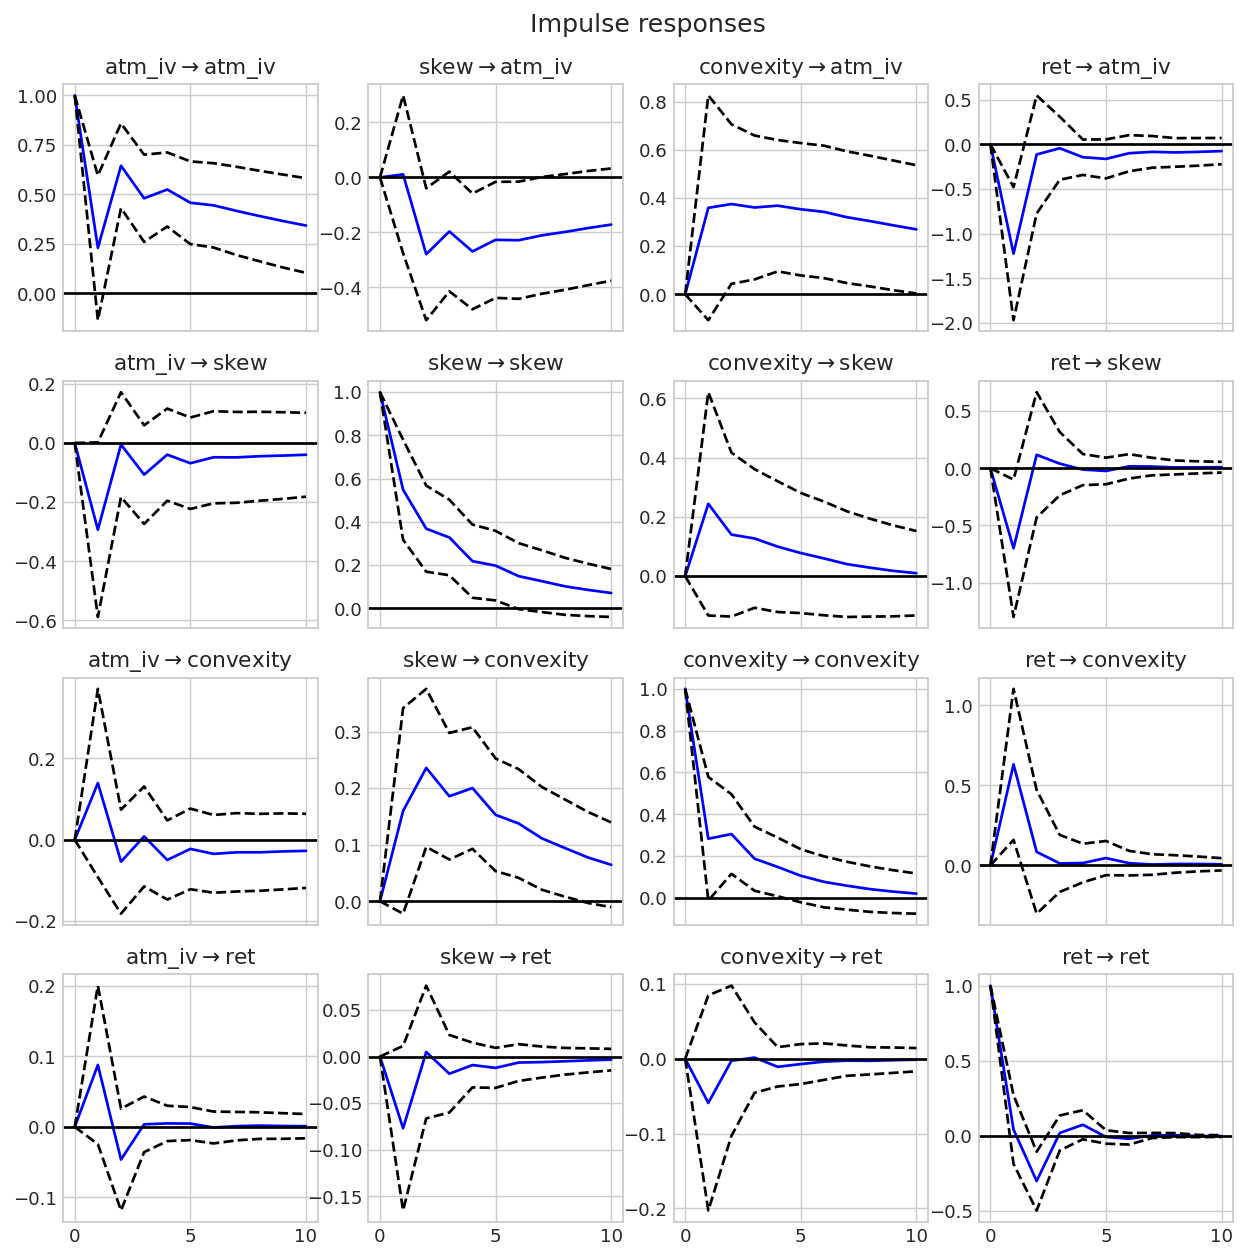

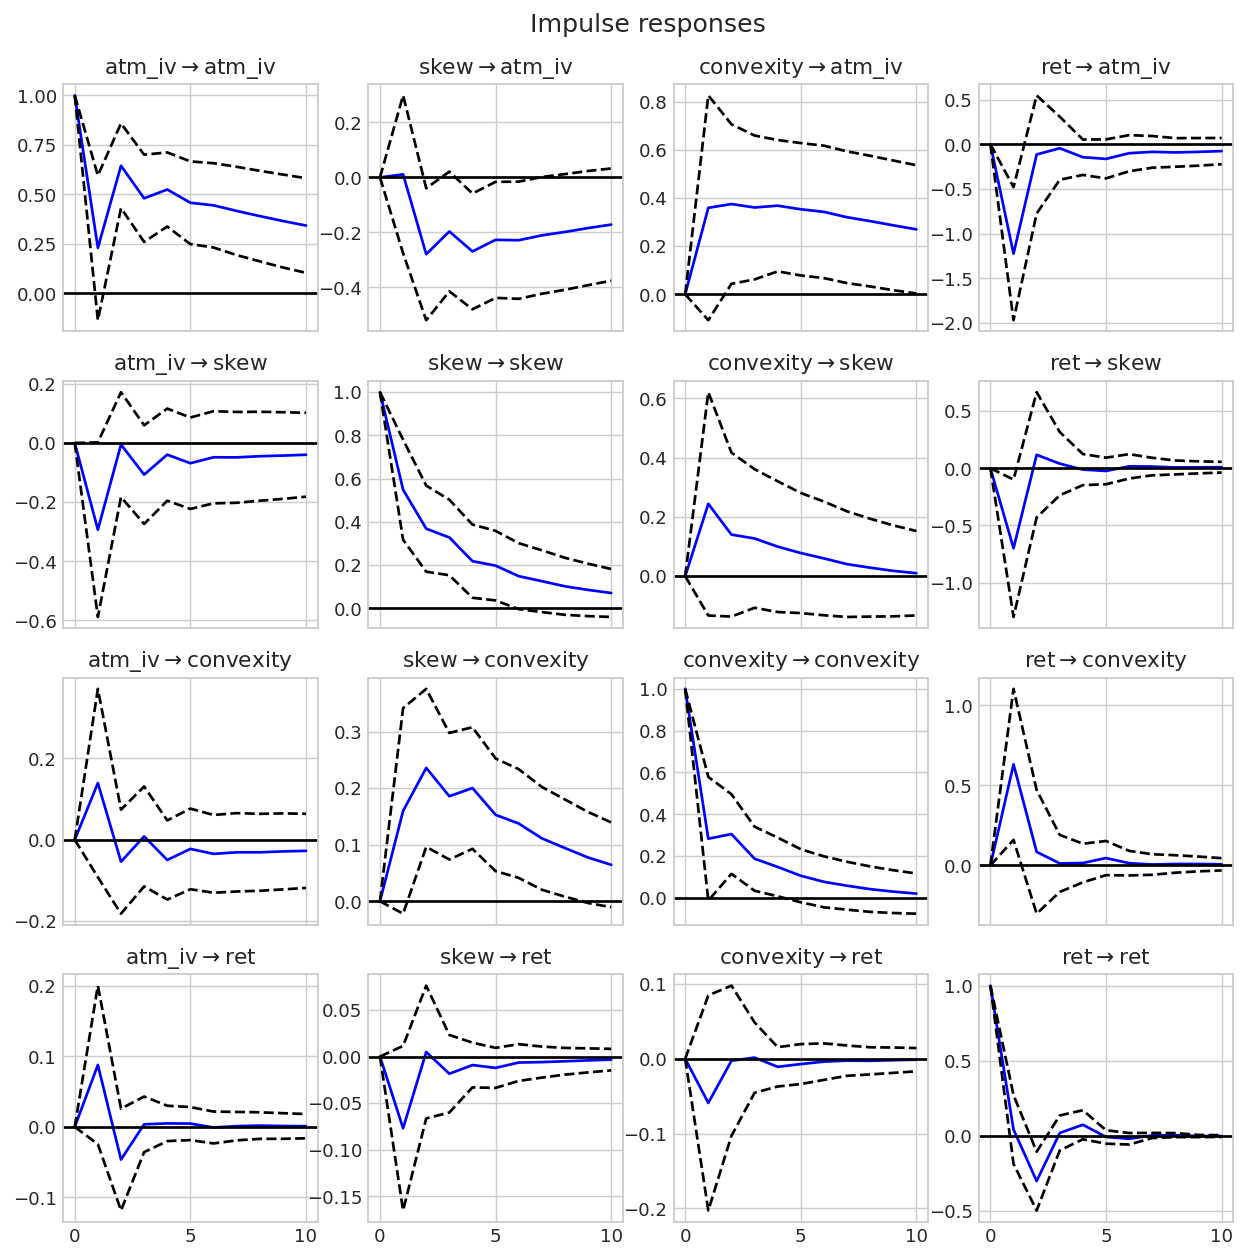

In [73]:
# impulse response functions
irf = results.irf(10) # 10 periods horizon
irf.plot(orth=False)

### VECM

In [74]:
from statsmodels.tsa.vector_ar.vecm import VECM

vecm = VECM(data_coint[['vix_norm', 'atm_iv', 'rv_past']], 
            k_ar_diff=1, coint_rank=2, deterministic='n')
vecm_fit = vecm.fit()
print(vecm_fit.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation vix_norm
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
L1.vix_norm    -0.0750      0.115     -0.652      0.514      -0.301       0.151
L1.atm_iv      -0.0551      0.065     -0.847      0.397      -0.183       0.072
L1.rv_past      0.0672      0.129      0.522      0.602      -0.185       0.320
Det. terms outside the coint. relation & lagged endog. parameters for equation atm_iv
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
L1.vix_norm     0.1712      0.176      0.970      0.332      -0.175       0.517
L1.atm_iv      -0.4280      0.100     -4.293      0.000      -0.623      -0.233
L1.rv_past     -0.3876      0.198     -1.962      0.050      -0.775      -0.000
Det. terms outside the coi